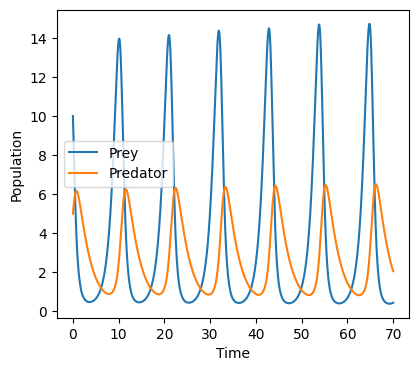

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def lotka_volterra(t, state, a, b, c, d):
    x, y = state
    dxdt = a*x - b*x*y
    dydt = d*x*y - c*y
    return [dxdt, dydt]

params = (1.1, 0.4, 0.4, 0.1)
initial_pop = [10, 5]
t_span = (0, 70)
t_eval = np.linspace(0, 70, 100000)

sol = solve_ivp(
    lotka_volterra,
    t_span,
    initial_pop,
    args=params,
    t_eval=t_eval
)

plt.figure(figsize=(10, 4))

# Time Series Plot
plt.subplot(1, 2, 1)
plt.plot(sol.t, sol.y[0], label='Prey')
plt.plot(sol.t, sol.y[1], label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()

plt.show()



Discovered Equations:
(x)' = -0.032 1 +  1.105 x +  0.027 y + -0.001 x^2 + -0.399 x y + -0.005 y^2
(y)' =  0.012 1 + -0.002 x + -0.409 y +  0.100 x y +  0.002 y^2


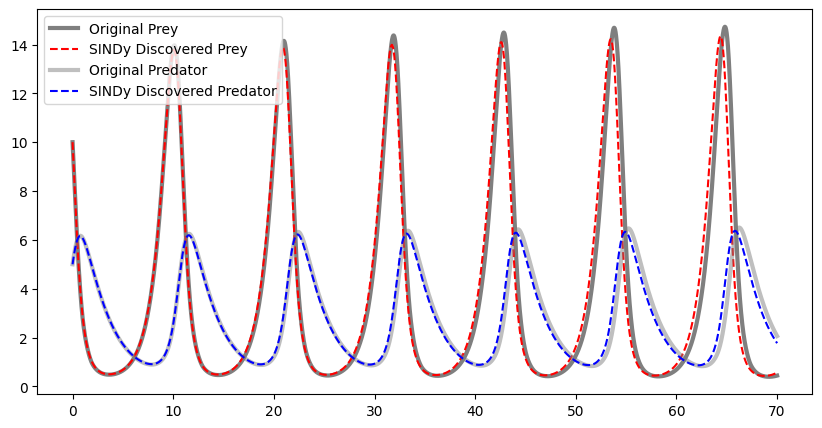

--- Error Metrics ---
Prey (x) RMSE: 0.9378
Predator (y) RMSE: 0.3383
12
[[-3.24399195e-02  1.10537956e+00  2.68702525e-02 -5.50318012e-04
  -3.99247971e-01 -5.31418581e-03]
 [ 1.16501716e-02 -2.05406118e-03 -4.08931250e-01  1.84171495e-04
   9.98229653e-02  1.65514247e-03]]


In [17]:
import pysindy as ps


x = sol.y[0]
y = sol.y[1]
t = sol.t

differentiation_method = ps.FiniteDifference(order=2)
feature_library = ps.PolynomialLibrary(degree=2)

optimizer = ps.STLSQ(threshold=1e-24)
model = ps.SINDy(
    differentiation_method=differentiation_method,
    feature_library=feature_library,
    optimizer=optimizer,
)
# look into model complexity
X = np.stack((x, y), axis=-1)
model.fit(X, t=t, feature_names=["x", "y"])

print("Discovered Equations:")
model.print()

x_sim = model.simulate(initial_pop, t_eval)

plt.figure(figsize=(10, 5))
plt.plot(t_eval, sol.y[0], 'k', label='Original Prey', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 0], 'r--', label='SINDy Discovered Prey')
plt.plot(t_eval, sol.y[1], 'gray', label='Original Predator', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 1], 'b--', label='SINDy Discovered Predator')
plt.legend()
plt.show()

# Extract the 1D arrays for original and simulated data
x_orig = sol.y[0]
y_orig = sol.y[1]
x_simulated = x_sim[:, 0]
y_simulated = x_sim[:, 1]

mse_x = np.mean((x_orig - x_simulated)**2)
mse_y = np.mean((y_orig - y_simulated)**2)

rmse_x = np.sqrt(mse_x)
rmse_y = np.sqrt(mse_y)

print("--- Error Metrics ---")
print(f"Prey (x) RMSE: {rmse_x:.4f}")
print(f"Predator (y) RMSE: {rmse_y:.4f}")
print(model.complexity)
print(model.coefficients())

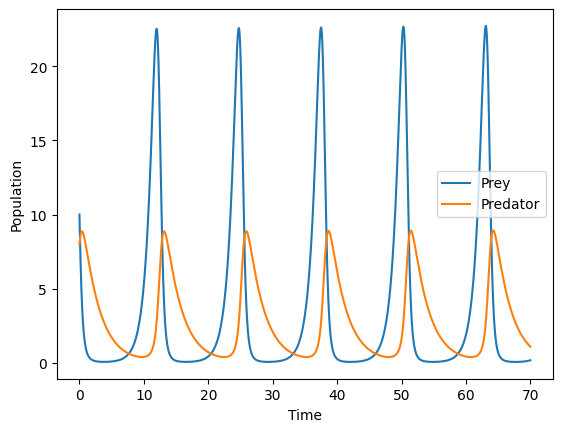

In [70]:
initial_pop = [10, 8]
t_span = (0, 70)
t_eval = np.linspace(0, 70, 10000)

sol = solve_ivp(
    lotka_volterra,
    t_span,
    initial_pop,
    args=params,
    t_eval=t_eval
)


# Time Series Plot
plt.plot(sol.t, sol.y[0], label='Prey')
plt.plot(sol.t, sol.y[1], label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()

plt.show()

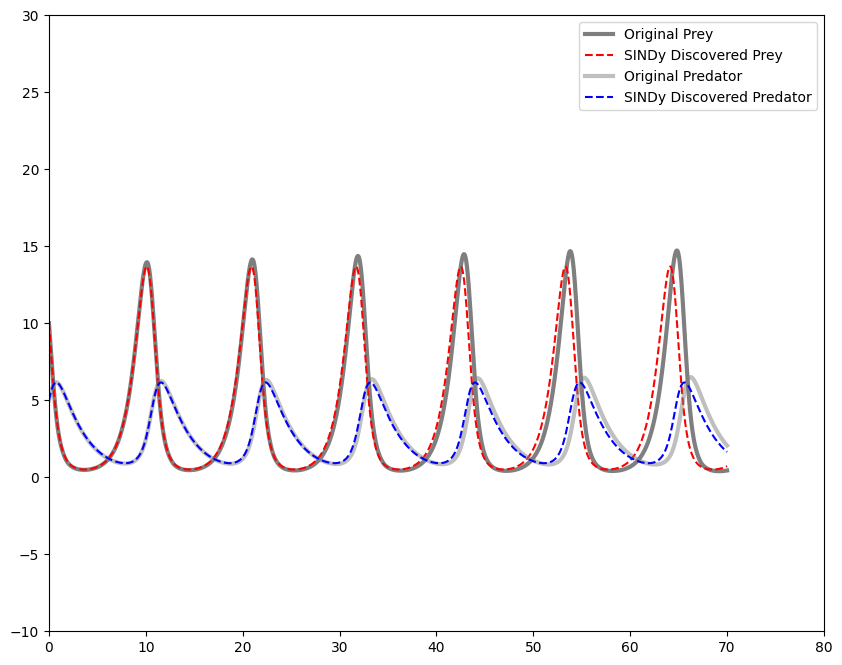

In [74]:
x_sim = model.simulate(initial_pop, t_eval)
plt.figure(figsize=(10, 8))

plt.plot(t_eval, sol.y[0], 'k', label='Original Prey', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 0], 'r--', label='SINDy Discovered Prey')
plt.plot(t_eval, sol.y[1], 'gray', label='Original Predator', alpha=0.5, linewidth=3)
plt.plot(t_eval, x_sim[:, 1], 'b--', label='SINDy Discovered Predator')
plt.xlim((0,80))
plt.ylim((-10,30))
plt.legend()
plt.show()